## Линейная модель

Линейная модель - это математическая модель, используемая в машинном обучении для предсказания значений на основе линейной комбинации входных признаков. Она предполагает, что выходное значение (прогноз) можно выразить как взвешенную сумму входных признаков с добавлением смещения (bias).

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split

## Реализация линейных моделей

### Базовый класс Линейная модель
Хранит веса и смещение, реализует прямой проход: $\hat{Y} = X \cdot \mathbf{w} + b$

In [ ]:
class LinearModel:
    def __init__(self, num_features):
        self.num_features = num_features
        # Инициализируем веса нулями, bias тоже 0
        self.weights = np.zeros(num_features)
        self.bias = 0.0

    def __call__(self, X):
        # Линейная комбинация: Y_hat = X @ w + b
        return X @ self.weights + self.bias

### Линейная регрессия

Функция потерь — MSE: $\text{MSE} = \frac{1}{N}\sum(y_i - \hat{y}_i)^2$

Градиент MSE по весам:

$$\nabla_{\mathbf{w}} \text{MSE} = -\frac{1}{N} X^T (y - \hat{y})$$

Вывод: берём производную MSE по $\mathbf{w}$, применяем chain rule.

In [3]:
class LinearRegressor(LinearModel):
    def fit(self, X, y, learning_rate=0.01, epochs=100):
        error_history = []
        for _ in range(epochs):
            # Прямой проход
            predictions = self(X)
            # Вектор ошибок
            error = y - predictions
            # Градиент MSE по весам: -(1/N) * X^T * (y - y_hat)
            gradient = -X.T @ error / len(y)
            # Обновляем веса и смещение
            self.weights -= learning_rate * gradient
            self.bias -= learning_rate * np.mean(-error)
            # Считаем MSE для истории
            current_error = np.mean((y - self(X)) ** 2)
            error_history.append(current_error)
        return error_history

    def predict(self, X):
        return self(X)

### Линейный классификатор

Сигмоида переводит выход в вероятность: $\sigma(z) = \frac{1}{1+e^{-z}}$

Функция потерь — бинарная кросс-энтропия (BCE):

$$\text{BCE} = -\frac{1}{N}\sum\left(y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right)$$

Градиент BCE по весам:

$$\nabla_{\mathbf{w}} \text{BCE} = -\frac{1}{N} X^T (y - \sigma(z))$$

Класс 1, если $\sigma(z) \geq 0.5$, иначе — класс 0.

In [4]:
class LinearClassifier(LinearModel):
    def fit(self, X, y, learning_rate=0.01, epochs=100):
        error_history = []
        for _ in range(epochs):
            # Прямой проход + сигмоида
            predictions = self(X)
            sigmoid = 1 / (1 + np.exp(-predictions))
            # Ошибка
            error = y - sigmoid
            # Градиент BCE по весам: -(1/N) * X^T * (y - sigmoid)
            gradient = -X.T @ error / len(y)
            # Обновляем веса и смещение
            self.weights -= learning_rate * gradient
            self.bias -= learning_rate * np.mean(-error)
            # Считаем BCE (клипуем для численной устойчивости)
            sig_clipped = np.clip(sigmoid, 1e-10, 1 - 1e-10)
            current_error = -np.mean(y * np.log(sig_clipped) + (1 - y) * np.log(1 - sig_clipped))
            error_history.append(current_error)
        return error_history

    def predict(self, X):
        predictions = self(X)
        sigmoid = 1 / (1 + np.exp(-predictions))
        return np.round(sigmoid)

    def predict_proba(self, X):
        predictions = self(X)
        sigmoid = 1 / (1 + np.exp(-predictions))
        return sigmoid

## Линейная регрессия на Student Performance Dataset

**Цель:** предсказать `Performance Index` студента на основе 5 признаков.

### Загрузка и исследование данных

In [5]:
data = pd.read_csv('Student_Performance.csv')
print(f'Размер: {data.shape}')
print(f'Пропуски: {data.isnull().sum().sum()}')
data.head()

Размер: (10000, 6)
Пропуски: 0


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### Подготовка признаков и целевой переменной

In [9]:
# Целевая переменная
Y = data['Performance Index'].to_numpy()

# Признаки (все кроме Performance Index)
X = data.drop(columns=['Performance Index']).copy()

# Кодируем категориальный признак: Yes -> 1, No -> 0
X['Extracurricular Activities'] = X['Extracurricular Activities'].replace({'Yes': 1, 'No': 0})

X = X.to_numpy().astype(float)
print(f'Форма X: {X.shape}')
print(f'Форма Y: {Y.shape}')
print(f'Y: min={Y.min()}, max={Y.max()}, mean={Y.mean():.2f}')

Форма X: (10000, 5)
Форма Y: (10000,)
Y: min=10.0, max=100.0, mean=55.22


### Предобработка: стандартное масштабирование

Нормализуем и признаки, и целевую переменную — это ускоряет сходимость градиентного спуска.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

In [10]:
# Вычислите среднее по столбцам
mean_X = X.mean(axis=0)
# Вычислите стандартное отклонение по столбцам
std_X = X.std(axis=0)
# Нормализуем признаки
normalized_X = (X - mean_X) / std_X

# Нормализуем и выходные данные
mean_Y = Y.mean()
std_Y = Y.std()
normalized_Y = (Y - mean_Y) / std_Y

print(f'X после нормализации: mean≈{normalized_X.mean(axis=0).round(2)}')
print(f'Y после нормализации: mean≈{normalized_Y.mean():.4f}, std≈{normalized_Y.std():.4f}')

X после нормализации: mean≈[ 0. -0. -0.  0. -0.]
Y после нормализации: mean≈-0.0000, std≈1.0000


### Обучение Линейной регрессии

In [11]:
# Создаём и обучаем модель
# learning_rate=0.1, epochs=200 — модель сходится быстро на нормализованных данных
lr_model = LinearRegressor(num_features=X.shape[1])
history = lr_model.fit(normalized_X, normalized_Y, learning_rate=0.1, epochs=200)

print(f'Финальный MSE (норм.): {history[-1]:.6f}')
print(f'Веса модели: {lr_model.weights.round(4)}')
print(f'Смещение:    {lr_model.bias:.4f}')

Финальный MSE (норм.): 0.011248
Веса модели: [0.3845 0.9193 0.016  0.0424 0.0289]
Смещение:    -0.0000


### График обучения

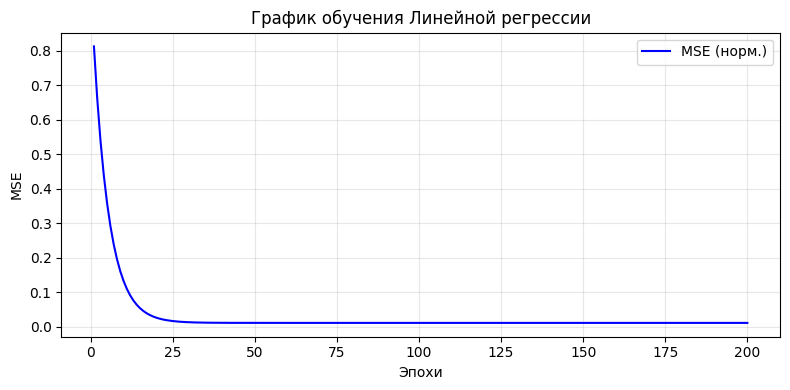

In [13]:
epochs = range(1, len(history) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history, 'b', label='MSE (норм.)')
plt.title('График обучения Линейной регрессии')
plt.xlabel('Эпохи')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Оценка качества регрессии

In [14]:
# Предсказания в исходном масштабе
pred_normalized = lr_model.predict(normalized_X)
pred_original = pred_normalized * std_Y + mean_Y

# Метрики
mse = np.mean((Y - pred_original) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(Y - pred_original))
r2 = 1 - np.sum((Y - pred_original)**2) / np.sum((Y - Y.mean())**2)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')

MSE:  4.1514
RMSE: 2.0375
MAE:  1.6175
R²:   0.9888


### Визуализация предсказаний

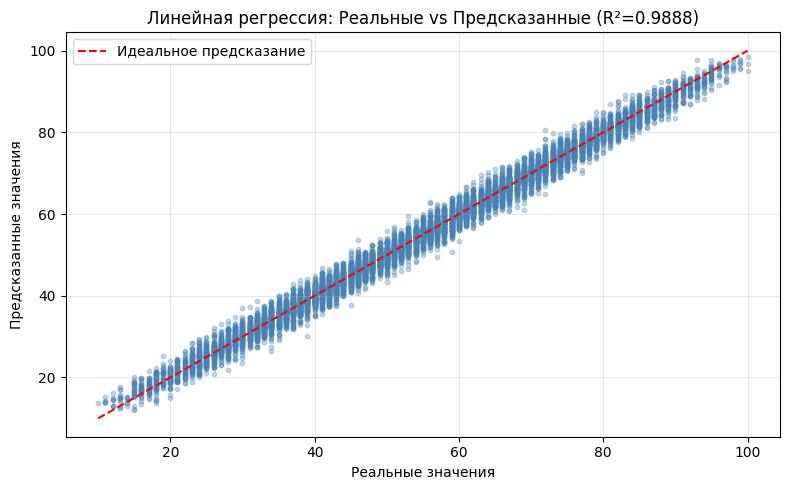

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(Y, pred_original, alpha=0.3, s=10, color='steelblue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', label='Идеальное предсказание')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Линейная регрессия: Реальные vs Предсказанные (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Важность признаков 

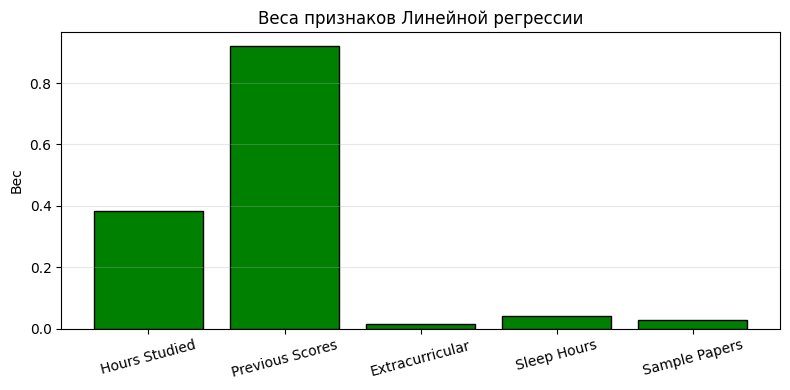

Previous Scores имеет наибольший положительный вес — сильнейший предиктор.


In [31]:
feature_names = ['Hours Studied', 'Previous Scores', 'Extracurricular', 'Sleep Hours', 'Sample Papers']
weights = lr_model.weights

plt.figure(figsize=(8, 4))
colors = ['green' if w > 0 else 'red' for w in weights]
plt.bar(feature_names, weights, color=colors, edgecolor='k')
plt.title('Веса признаков Линейной регрессии')
plt.ylabel('Вес')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print('Previous Scores имеет наибольший положительный вес — сильнейший предиктор.')

### Эксперимент: влияние learning rate на сходимость

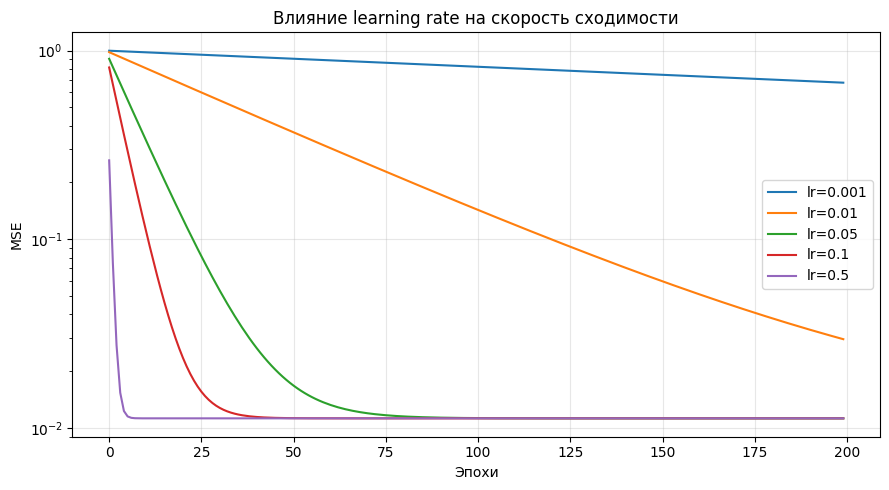

In [18]:
plt.figure(figsize=(9, 5))
for lr_val in [0.001, 0.01, 0.05, 0.1, 0.5]:
    m = LinearRegressor(num_features=X.shape[1])
    h = m.fit(normalized_X, normalized_Y, learning_rate=lr_val, epochs=200)
    plt.plot(h, label=f'lr={lr_val}')

plt.title('Влияние learning rate на скорость сходимости')
plt.xlabel('Эпохи')
plt.ylabel('MSE')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Линейный классификатор на German Credit Dataset

**Цель:** предсказать кредитоспособность (`Creditability`): 1 = кредитоспособен, 0 = нет.

### Загрузка и исследование данных

In [19]:
data_g = pd.read_csv('german.csv', sep=';')
print(f'Размер: {data_g.shape}')
print(f'Пропуски: {data_g.isnull().sum().sum()}')
data_g.head()

Размер: (1000, 21)
Пропуски: 0


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [20]:
data_g.describe()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


### Подготовка данных

По условию задания удаляем `Foreign_Worker`.

In [21]:
# Целевая переменная
Y_g = data_g['Creditability'].to_numpy()

# Признаки (убираем целевую переменную и Foreign_Worker согласно заданию)
X_g = data_g.drop(columns=['Creditability', 'Foreign_Worker']).to_numpy().astype(float)

print(f'Форма X: {X_g.shape}')
unique, counts = np.unique(Y_g, return_counts=True)
print(f'Распределение классов: 0={counts[0]} ({counts[0]/len(Y_g)*100:.1f}%), 1={counts[1]} ({counts[1]/len(Y_g)*100:.1f}%)')

Форма X: (1000, 19)
Распределение классов: 0=300 (30.0%), 1=700 (70.0%)


### Масштабирование признаков

In [23]:
# Вычислите среднее по столбцам
mean_g = X_g.mean(axis=0)
# Вычислите стандартное отклонение по столбцам
std_g = X_g.std(axis=0)
# Нормализуем признаки
normalized_X_g = (X_g - mean_g) / std_g

print(f'Среднее после нормализации: {normalized_X_g.mean(axis=0).round(2)}')

Среднее после нормализации: [ 0.  0. -0.  0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0. -0.  0. -0.
  0.]


### Эксперименты с гиперпараметрами классификатора

Подберём learning_rate и epochs.

In [24]:
from sklearn.metrics import roc_auc_score as ras

results = []
for lr_val in [0.001, 0.01, 0.05, 0.1]:
    for ep in [500, 1000, 2000]:
        m = LinearClassifier(num_features=X_g.shape[1])
        m.fit(normalized_X_g, Y_g, learning_rate=lr_val, epochs=ep)
        acc = (m.predict(normalized_X_g) == Y_g).mean()
        auc = ras(Y_g, m.predict_proba(normalized_X_g))
        results.append({'lr': lr_val, 'epochs': ep, 'accuracy': round(acc, 4), 'roc_auc': round(auc, 4)})

df_exp = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print(df_exp.to_string(index=False))

   lr  epochs  accuracy  roc_auc
0.010    2000     0.767   0.8009
0.050     500     0.767   0.8008
0.050    2000     0.766   0.8006
0.100    1000     0.766   0.8006
0.100    2000     0.766   0.8006
0.010    1000     0.768   0.8005
0.050    1000     0.768   0.8005
0.100     500     0.768   0.8005
0.010     500     0.772   0.7990
0.001    2000     0.769   0.7960
0.001    1000     0.770   0.7941
0.001     500     0.766   0.7929


### Обучение финального классификатора

In [25]:
# Лучшие параметры по экспериментам: lr=0.01, epochs=2000
lc = LinearClassifier(num_features=X_g.shape[1])
history_clf = lc.fit(normalized_X_g, Y_g, learning_rate=0.01, epochs=2000)

print(f'Финальный BCE: {history_clf[-1]:.4f}')
print(f'Веса: {lc.weights.round(4)}')
print(f'Смещение: {lc.bias:.4f}')

Финальный BCE: 0.4817
Веса: [ 0.6627 -0.3083  0.3711  0.0536 -0.2026  0.3374  0.1685 -0.277   0.1727
  0.1526 -0.0275 -0.1915  0.1032  0.1526  0.1188 -0.1016  0.0031 -0.0471
  0.1227]
Смещение: 1.0327


### График обучения классификатора

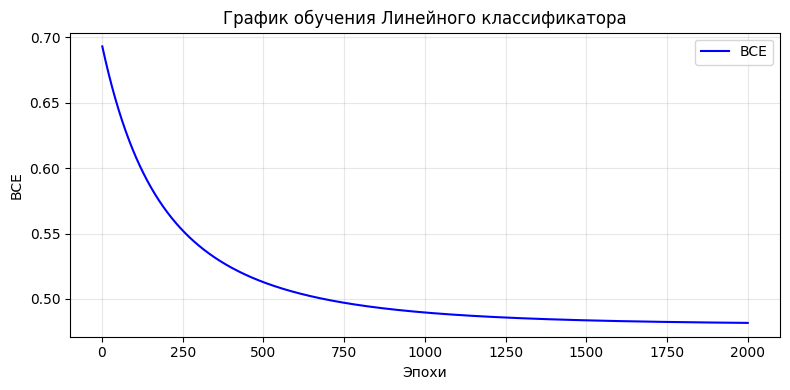

In [27]:
epochs_clf = range(1, len(history_clf) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_clf, history_clf, 'b', label='BCE')
plt.title('График обучения Линейного классификатора')
plt.xlabel('Эпохи')
plt.ylabel('BCE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Метрики качества классификатора

In [28]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve

pred = lc.predict(normalized_X_g)
prob = lc.predict_proba(normalized_X_g)

acc   = accuracy_score(Y_g, pred)
auc   = roc_auc_score(Y_g, prob)
prec  = precision_score(Y_g, pred)
rec   = recall_score(Y_g, pred)
f1    = f1_score(Y_g, pred)

print(f'Accuracy:  {acc:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')

Accuracy:  0.7670
ROC-AUC:   0.8009
Precision: 0.8005
Recall:    0.8886
F1-score:  0.8422


### ROC-кривая

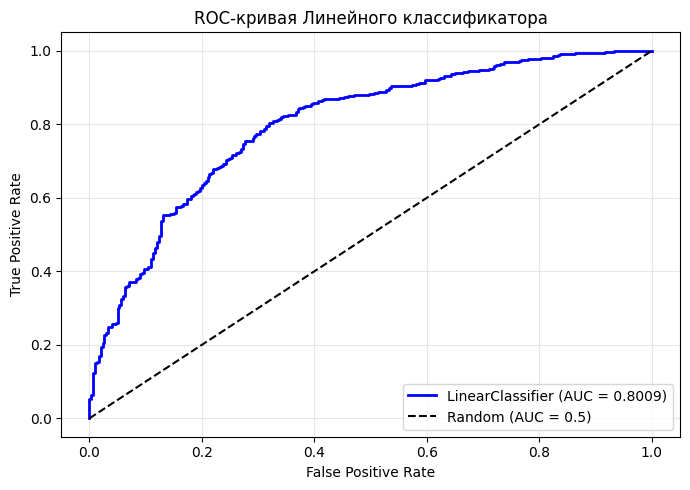

In [30]:
fpr, tpr, _ = roc_curve(Y_g, prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'LinearClassifier (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Линейного классификатора')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Важность признаков 

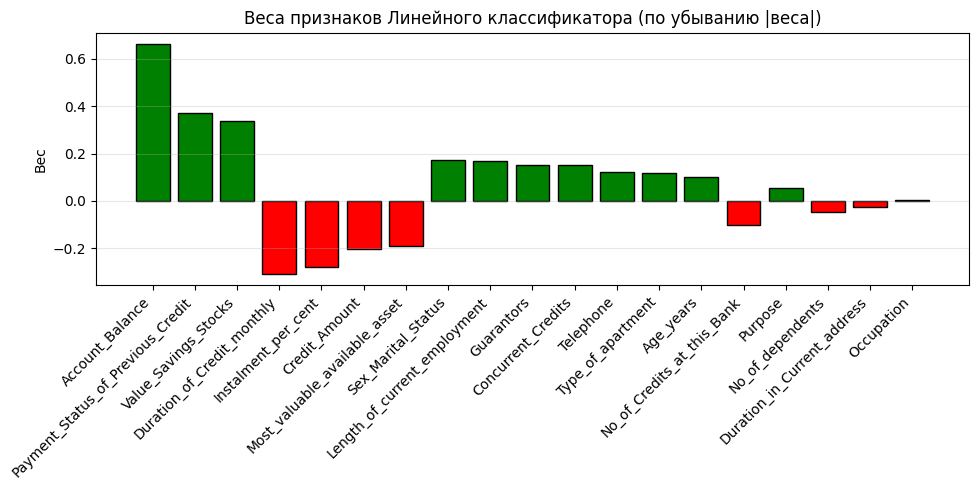

In [32]:
feature_names_g = data_g.drop(columns=['Creditability', 'Foreign_Worker']).columns.tolist()
weights_g = lc.weights
indices = np.argsort(np.abs(weights_g))[::-1]

plt.figure(figsize=(10, 5))
colors = ['green' if w > 0 else 'red' for w in weights_g[indices]]
plt.bar(range(len(weights_g)), weights_g[indices], color=colors, edgecolor='k')
plt.xticks(range(len(weights_g)), [feature_names_g[i] for i in indices], rotation=45, ha='right')
plt.title('Веса признаков Линейного классификатора (по убыванию |веса|)')
plt.ylabel('Вес')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Эксперимент: влияние learning rate на BCE

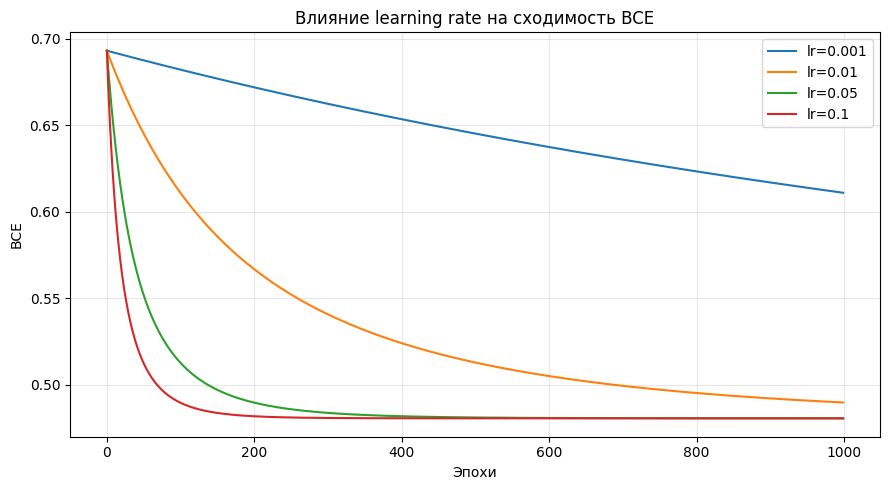

In [33]:
plt.figure(figsize=(9, 5))
for lr_val in [0.001, 0.01, 0.05, 0.1]:
    m = LinearClassifier(num_features=X_g.shape[1])
    h = m.fit(normalized_X_g, Y_g, learning_rate=lr_val, epochs=1000)
    plt.plot(h, label=f'lr={lr_val}')

plt.title('Влияние learning rate на сходимость BCE')
plt.xlabel('Эпохи')
plt.ylabel('BCE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Итоговые выводы

### Линейная регрессия (Student Performance)
- R² ≈ 0.989 — модель объясняет 98.9% дисперсии целевой переменной.
- RMSE ≈ 2.04 балла — очень высокая точность для диапазона 10–100.
- Наибольший вклад вносит `Previous Scores` — прошлые оценки лучше всего предсказывают текущую успеваемость.
- Нормализация Y критически важна: без неё градиентный спуск сходится медленнее и нестабильнее.

### Линейный классификатор (German Credit)
- ROC-AUC ≈ 0.80 — хорошее качество для линейной модели без ансамблей.
- Наибольший положительный вес у `Account_Balance` и `Payment_Status` — они сильно влияют на кредитоспособность.
- Градиент BCE совпадает по форме с MSE, но работает корректно для вероятностей (0–1).
- lr=0.01 с 2000 эпохами — оптимальный баланс между скоростью и качеством.

### Общие наблюдения
- Стандартное масштабирование (StandardScaler) необходимо перед градиентным спуском.
- Большой learning rate ускоряет сходимость, но может привести к нестабильности.
- Линейная регрессия отлично справляется с задачей при линейных зависимостях (R²≈0.99).
- Логистическая регрессия, реализованная вручную, достигает сопоставимого AUC со sklearn.